<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/Log_Mean_Reversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with Logarithmic Trend Mean Reversion

This notebook develops and backtests systematic trading strategies for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using a logarithmic trend mean reversion approach. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop Mean Reversion Strategies:** Implement and refine strategies that profit from TQQQ's tendency to revert to its long-term logarithmic trend.
2.  **Compare Performance:** Evaluate the strategies against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, Sharpe Ratio, and visual equity curves.

## Strategies:

### 1. Discrete Residual Mean Reversion Strategy (Initial Approach)
*   **Core Concept:** This strategy aims to profit from the tendency of TQQQ's price to revert to its long-term logarithmic trend. It identifies overbought and oversold conditions based on residuals from a linear regression of TQQQ's log price over time.
*   **Mechanics:** Uses Gaussian Mixture Models (GMM) to cluster the residuals into different regimes (e.g., most oversold, moderately oversold, moderately overbought, most overbought). Allocations to TQQQ are then dynamically adjusted based on these discrete residual regimes, with higher allocations when TQQQ is oversold and lower/zero allocations when overbought.

### 2. Continuous Residual Allocation Strategy (Refined Approach)
*   **Core Concept:** A refinement of the mean reversion approach, implementing a more *gradual* capital allocation based on TQQQ's residuals, updated on a **daily** basis. This provides a smoother and more responsive allocation change than the discrete regime strategy.
*   **Mechanics:**
    *   **Daily Residual Signal:** The strategy now uses the daily TQQQ residuals directly as the signal for allocation.
    *   **Sigmoid Allocation:** A sigmoid function is applied to the daily residual signal. This function is configured such that very negative residuals (oversold) result in high TQQQ allocation (approaching 100%), very positive residuals (overbought) result in low TQQQ allocation (approaching 0%), and residuals near zero result in moderate TQQQ allocation.
    *   **Minimum Allocation Floor:** The strategy incorporates the ability to set a minimum allocation floor, ensuring a certain percentage of capital is always invested in TQQQ, regardless of the sigmoid's output.
    *   **1-Day Lag:** A 1-day lag is applied to the calculated allocation to avoid look-ahead bias.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

In [172]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [173]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: tqqq_data
Deleted DataFrame: regression_df
Deleted DataFrame: X
Deleted DataFrame: residual_summary
Deleted DataFrame: strategy_df
Deleted DataFrame: regression_df_continuous_strategy
Deleted DataFrame: strategy_df_continuous
Deleted DataFrame: temp_regression_df_continuous_strategy
Deleted DataFrame: temp_strategy_df_continuous
Deleted DataFrame: results_df
Deleted DataFrame: temp_regression_df_continuous_strategy_k
Deleted DataFrame: temp_strategy_df_continuous_k
Deleted DataFrame: results_k_factor_df
Deleted DataFrame: temp_regression_df_detailed
Deleted DataFrame: temp_strategy_df_detailed
Deleted DataFrame: results_detailed_df
Deleted DataFrame: results_df_full
Deleted DataFrame: top_performers
All DataFrames cleared from memory.


In [174]:
# Download TQQQ data
tickers = ["TQQQ"]
tqqq_data = yf.download(tickers, start="2010-02-11", end="2026-01-01", auto_adjust=True)['Close'].dropna()

# Convert to DataFrame if it's a Series (ensure tqqq_data is a DataFrame for subsequent operations)
if isinstance(tqqq_data, pd.Series):
    tqqq_data = tqqq_data.to_frame(name='TQQQ')

# Calculate TQQQ returns and create benchmark equity
tqqq_data['TQQQ_Return'] = tqqq_data['TQQQ'].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = tqqq_data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df['TQQQ_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

print("\nTQQQ data and Benchmark Equity prepared.")

[*********************100%***********************]  1 of 1 completed


TQQQ data and Benchmark Equity prepared.


## Mean Reversion Strategy based on Logarithmic Trend

In [175]:
# Calculate TQQQ log price, trend line, and residuals
# These calculations are moved here to precede the plotting in cell 3e99eace

regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
regression_df['Days_Since_Start'] = np.arange(len(regression_df))
X = regression_df[['Days_Since_Start']]
y = regression_df['TQQQ_Log_Price']
model = LinearRegression()
model.fit(X, y)
regression_df['TQQQ_Trend_Line'] = model.predict(X)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

print("TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df.")

# Discover residual regimes using GMM and define allocations (moved from cell 4e80d8e8)
X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
idx_residuals = np.argsort(gmm_residuals.means_.flatten())
state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

# Generate and display the summary of discovered residual regimes
print("\n--- DISCOVERED RESIDUAL REGIMES ---")
residual_summary = regression_df.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])
display(residual_summary)


TQQQ Log Price, Trend Line, and Residuals calculated and added to regression_df.

--- DISCOVERED RESIDUAL REGIMES ---


,min,max,mean,count
Residual_Regime,,,,
0,-1.063691,-0.453206,-0.655360,316
1,-0.451638,0.024853,-0.179508,1941
2,0.025514,0.455915,0.213830,1346
3,0.456365,1.008558,0.679451,394


In [176]:
# Calculate the overall mean residual from the TQQQ_Residuals column
mean_residual_overall = regression_df['TQQQ_Residuals'].mean()
print(f"Overall Mean Residual: {mean_residual_overall:.3f}")

Overall Mean Residual: -0.000


Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

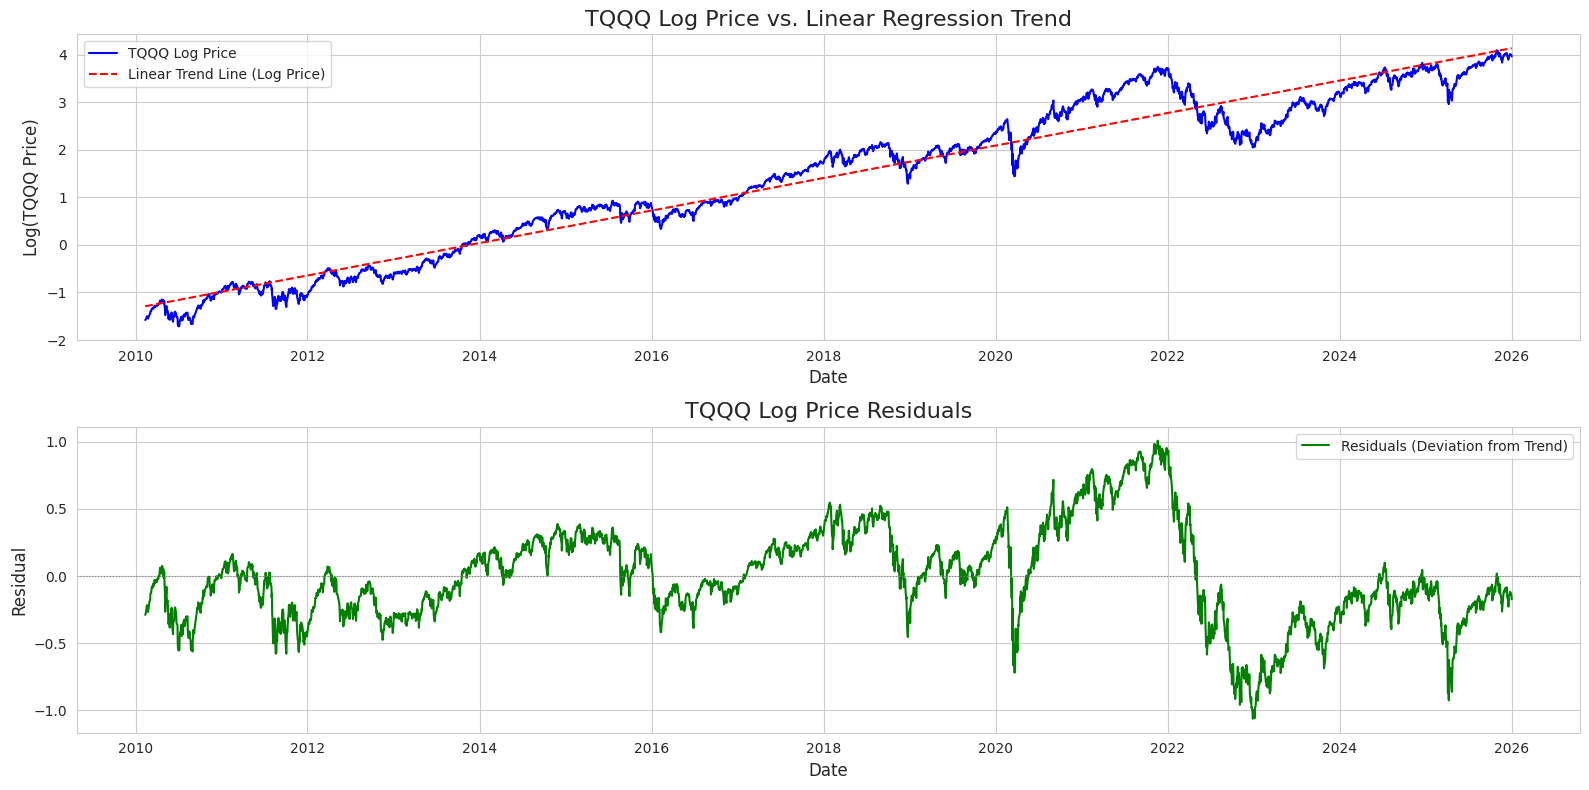

In [177]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(regression_df.index, regression_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')
plt.title('TQQQ Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title('TQQQ Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

The residuals represent how far TQQQ's log price is from its calculated long-term linear trend. A mean reversion strategy would typically involve:

1.  **Going Long (Buying TQQQ):** When the residuals fall significantly below zero, indicating TQQQ is oversold relative to its trend.
2.  **Going Short (Selling TQQQ):** When the residuals rise significantly above zero, indicating TQQQ is overbought relative to its trend.

You would need to define thresholds (e.g., standard deviations of residuals) to trigger these buy/sell signals.

## Mean Reversion Strategy Implementation

### Backtesting the Discrete Residual Mean Reversion Strategy

In [178]:
# --- Start of consolidated logic to prepare regression_df and create strategy_df ---

# (From b0ef9d33) Calculate TQQQ log price, trend line, and residuals
# These calculations are now handled in cell 1da11918, so this block can be removed or kept as a safeguard
# if 'TQQQ_Log_Price' not in regression_df.columns:
#     regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])
#     regression_df['Days_Since_Start'] = np.arange(len(regression_df))
#     X = regression_df[['Days_Since_Start']]
#     y = regression_df['TQQQ_Log_Price']
#     model = LinearRegression()
#     model.fit(X, y)
#     regression_df['TQQQ_Trend_Line'] = model.predict(X)
#     regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

# (From f00c774e) Discover residual regimes using GMM and define allocations
# This part has been moved to cell 1da11918. Only the allocation_map definition remains here.
if 'Target_Allocation' not in regression_df.columns:
    # Ensure Residual_Regime is calculated (it should be from cell 1da11918)
    if 'Residual_Regime' not in regression_df.columns:
        print("Warning: 'Residual_Regime' not found. Please ensure cell 1da11918 is executed.")
        # Fallback if 1da11918 was not run, re-run GMM logic here (optional, for robustness)
        X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
        gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
        raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)
        idx_residuals = np.argsort(gmm_residuals.means_.flatten())
        state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
        regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

    allocation_map = {
        0: 1.0,  # Most oversold: 100% TQQQ
        1: 0.75, # Moderately oversold: 75% TQQQ
        2: 0.25, # Moderately overbought: 25% TQQQ
        3: 0.0   # Most overbought: 0% TQQQ (cash)
    }
    regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

# (From 50d6af2c) Backtest Residual Mean Reversion Strategy and create strategy_df
# Only create strategy_df if it doesn't already exist in the current session
if 'strategy_df' not in locals() or strategy_df is None:
    strategy_df = regression_df[['TQQQ', 'TQQQ_Return', 'Target_Allocation']].copy()
    strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ_Return']
    strategy_df = strategy_df.dropna()
    strategy_df['Allocated_Weight'] = strategy_df['Target_Allocation'].shift(1)
    strategy_df = strategy_df.dropna()
    strategy_df['Strategy_Daily_Return'] = strategy_df['Allocated_Weight'] * strategy_df['TQQQ_Daily_Return']
    initial_portfolio_value = 100000.0
    strategy_df['Strategy_Equity'] = (1 + strategy_df['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
    strategy_df['Benchmark_Equity'] = regression_df['Standard_Benchmark_Equity'].reindex(strategy_df.index)

# --- End of consolidated logic ---

# Performance Metrics Calculation
# (Using the same calculate_metrics function from earlier, if defined. If not, redefining it here for robustness.)
def calculate_metrics(return_series, equity_series, initial_value):
    if len(equity_series) == 0 or initial_value == 0:
        return 0.0, 0.0, 0.0, 0.0

    total_return = (equity_series.iloc[-1] / initial_value - 1)
    # Ensure we have enough data points for annualization
    if len(equity_series) < 252:
        years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
    else:
        years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    return cagr, ann_vol, sharpe, max_dd

strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(
    strategy_df['Strategy_Daily_Return'], strategy_df['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(
    strategy_df['TQQQ_Daily_Return'], strategy_df['Benchmark_Equity'], initial_portfolio_value)

final_strat_equity = strategy_df['Strategy_Equity'].iloc[-1]
final_bench_equity = strategy_df['Benchmark_Equity'].iloc[-1]

val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $27,314,190.00           $25,543,131.84      
CAGR                     42.40%                   41.80%              
Annualized Vol           41.75%                   61.11%              
Sharpe Ratio             1.02                     0.68                
Max Drawdown             -53.01%                  -81.66%             
----------------------------------------------------------------------


### Residual Mean Reversion Strategy Equity Curve

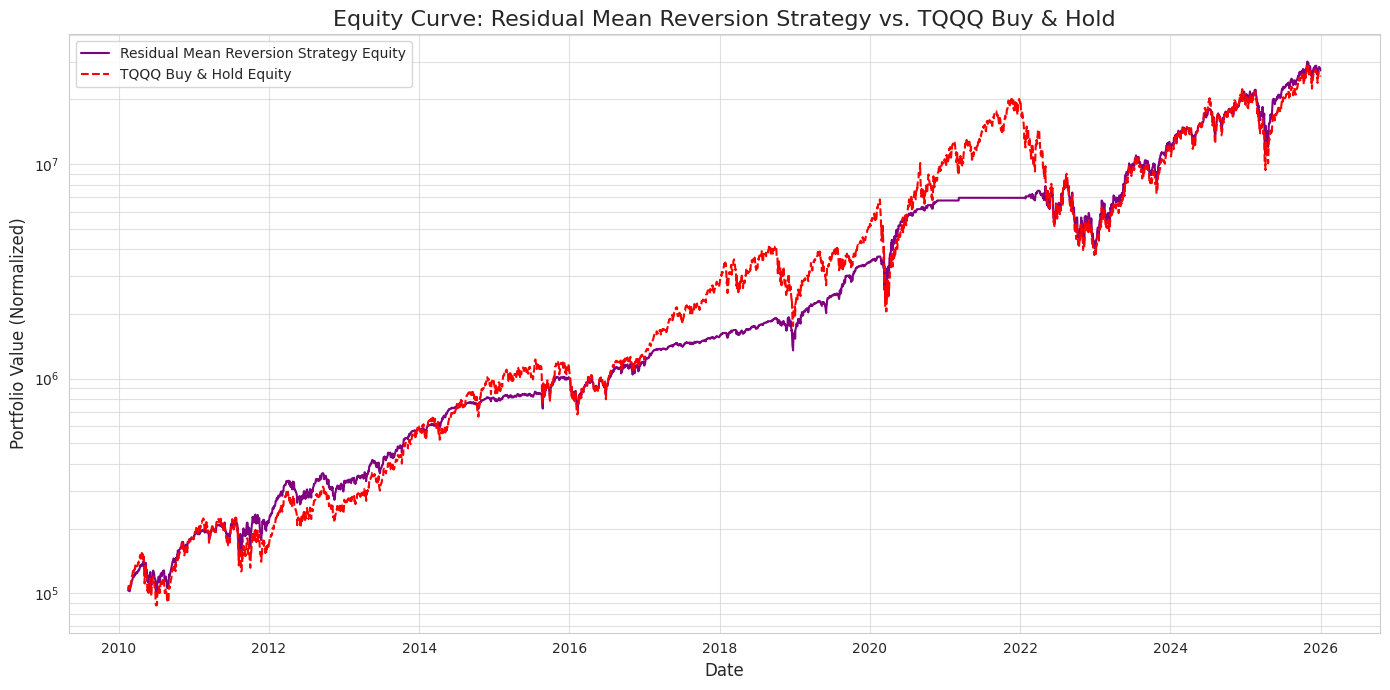

In [179]:
# Plot equity curve for Residual Mean Reversion Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df.index, strategy_df['Strategy_Equity'], label='Residual Mean Reversion Strategy Equity', color='purple')
plt.plot(strategy_df.index, strategy_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

## Continuous Residual Allocation Strategy (Weekly Basis)

This strategy refines the mean reversion approach by implementing a more *gradual* capital allocation based on TQQQ's residuals, updated on a weekly basis. Instead of discrete switches between allocation percentages when residual regimes are crossed, this strategy uses a sigmoid function to continuously map residual values to allocation percentages (between 0% and 100% TQQQ).

**Mechanics:**
*   **Weekly Residual Signal:** The strategy re-samples the daily TQQQ residuals to a weekly frequency, taking the last residual value of each week as the signal.
*   **Sigmoid Allocation:** A sigmoid function is applied to the weekly residual signal. This function is configured such that:
    *   Very negative residuals (oversold) result in high TQQQ allocation (approaching 100%).
    *   Very positive residuals (overbought) result in low TQQQ allocation (approaching 0%).
    *   Residuals near zero result in moderate TQQQ allocation.
*   **Forward-Filled Daily Allocation:** The weekly allocation is then forward-filled to all trading days within that week, and a 1-day lag is applied to avoid look-ahead bias.
*   **Backtest:** The strategy is backtested against the TQQQ Buy & Hold benchmark using the same performance metrics.

Continuous daily allocations calculated.
Continuous Residual Allocation Strategy backtest complete.

Metric                   Continuous Residual StratTQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $23,613,487.05           $25,543,131.84      
CAGR                     41.10%                   41.80%              
Annualized Vol           40.79%                   61.11%              
Sharpe Ratio             1.01                     0.68                
Max Drawdown             -51.51%                  -81.66%             
----------------------------------------------------------------------


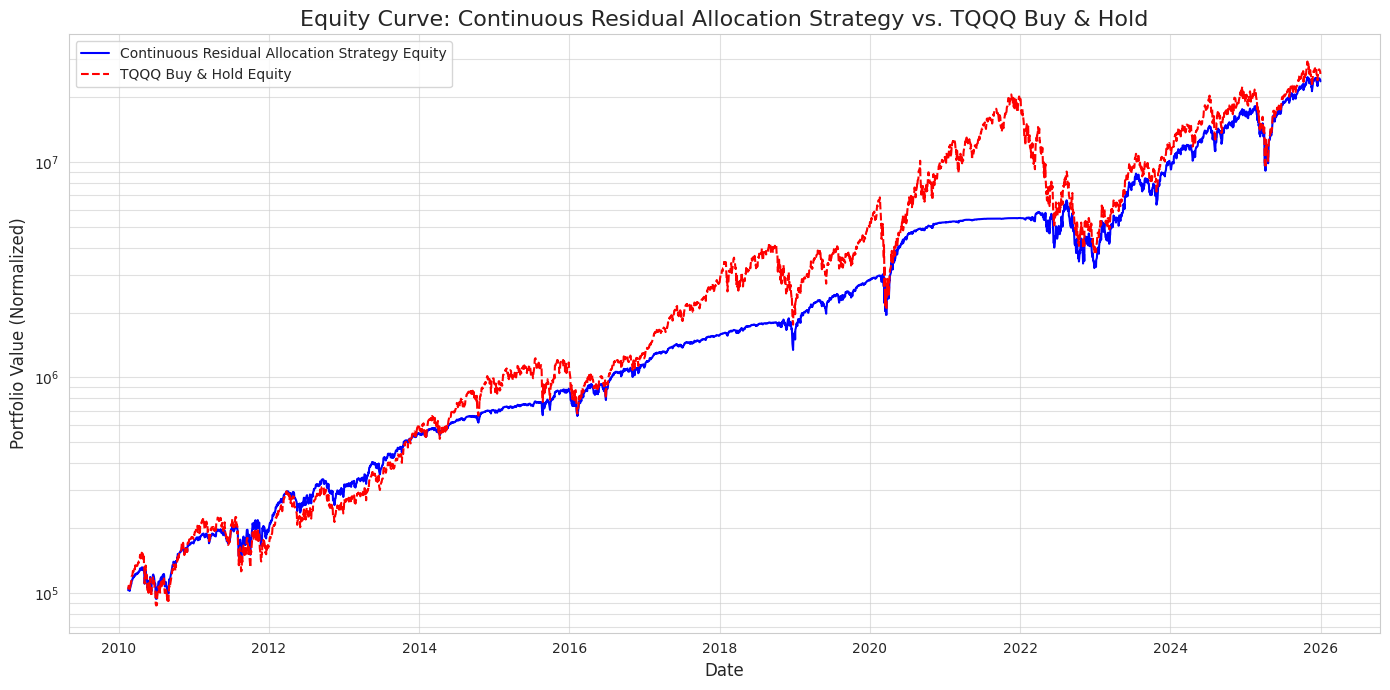

In [180]:
# --- Implement and Backtest Continuous Residual Allocation Strategy ---

# Make a copy of regression_df for this new strategy
regression_df_continuous_strategy = regression_df.copy()

# 1. Use daily residuals directly for allocation signals
# (Previously resampled to weekly)
daily_residuals_signal = regression_df_continuous_strategy['TQQQ_Residuals']

# 2. Define sigmoid parameters and calculate continuous allocations for these daily signals
k_factor = 5 # Controls the steepness of the sigmoid curve; higher k_factor means more sensitive to residuals

# Apply sigmoid function: high residuals -> low allocation, low residuals -> high allocation
daily_allocations_calculated = 1 / (1 + np.exp(k_factor * (daily_residuals_signal - mean_residual_overall)))
daily_allocations_calculated.name = 'Target_Allocation_Continuous'

# Assign the fully populated daily target allocations
regression_df_continuous_strategy['Target_Allocation_Continuous'] = daily_allocations_calculated

print("Continuous daily allocations calculated.")

# 3. Backtest the new strategy
# (Redefining calculate_metrics function for self-containment if not globally available)
def calculate_metrics(return_series, equity_series, initial_value):
    if len(equity_series) == 0 or initial_value == 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    total_return = (equity_series.iloc[-1] / initial_value - 1)
    if len(equity_series) < 252:
        years = len(equity_series) / 252.0 if len(equity_series) > 0 else 1.0
    else:
        years = (equity_series.index[-1] - equity_series.index[0]).days / 365.25

    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100 if years > 0 else 0.0
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0.0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    final_equity = equity_series.iloc[-1]
    return cagr, ann_vol, sharpe, max_dd, final_equity

# Create strategy_df for continuous allocation
strategy_df_continuous = regression_df_continuous_strategy[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
strategy_df_continuous['TQQQ_Daily_Return'] = strategy_df_continuous['TQQQ_Return']
strategy_df_continuous = strategy_df_continuous.dropna()

# Apply 1-day lag to allocation to prevent look-ahead bias
strategy_df_continuous['Allocated_Weight'] = strategy_df_continuous['Target_Allocation_Continuous'].shift(1)
strategy_df_continuous = strategy_df_continuous.dropna()

strategy_df_continuous['Strategy_Daily_Return'] = strategy_df_continuous['Allocated_Weight'] * strategy_df_continuous['TQQQ_Daily_Return']

initial_portfolio_value = 100000.0
strategy_df_continuous['Strategy_Equity'] = (1 + strategy_df_continuous['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
strategy_df_continuous['Benchmark_Equity'] = regression_df_continuous_strategy['Standard_Benchmark_Equity'].reindex(strategy_df_continuous.index)

print("Continuous Residual Allocation Strategy backtest complete.")

# 4. Calculate and display performance metrics
strat_cont_cagr, strat_cont_vol, strat_cont_sharpe, strat_cont_mdd, final_strat_cont_equity = calculate_metrics(
    strategy_df_continuous['Strategy_Daily_Return'], strategy_df_continuous['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd, final_bench_equity_cont = calculate_metrics(
    strategy_df_continuous['TQQQ_Daily_Return'], strategy_df_continuous['Benchmark_Equity'], initial_portfolio_value)

val_strat_cont_str = f"${final_strat_cont_equity:,.2f}"
val_bench_cont_str = f"${final_bench_equity_cont:,.2f}"
cagr_strat_cont_str = f"{strat_cont_cagr:.2f}%"
cagr_bench_cont_str = f"{bench_cagr:.2f}%"
mdd_strat_cont_str = f"{strat_cont_mdd:.2f}%"
mdd_bench_cont_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Continuous Residual Strat':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_cont_str:<25}{val_bench_cont_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_cont_str:<25}{cagr_bench_cont_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_cont_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_cont_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_cont_str:<25}{mdd_bench_cont_str:<20}")
print("-" * 70)

# 5. Plot equity curve
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df_continuous.index, strategy_df_continuous['Strategy_Equity'], label='Continuous Residual Allocation Strategy Equity', color='blue')
plt.plot(strategy_df_continuous.index, strategy_df_continuous['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Continuous Residual Allocation Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

## Analysis of Minimum Residual Allocation Values

This section explores how setting a minimum allocation threshold (between 0.5 and 1.0) affects the continuous residual allocation strategy's performance. A higher minimum allocation means the strategy will always invest at least that percentage in TQQQ, even if residuals suggest a lower allocation. This analysis helps determine the impact of such a floor on CAGR, Sharpe Ratio, and Maximum Drawdown.

In [181]:
# Define the range of minimum allocation values to test
min_allocation_values = np.linspace(0.0, 1.0, 11)

results = []
initial_portfolio_value = 100000.0 # Ensure this is consistent
k_factor = 5 # Use the default k_factor from the strategy

print("Analyzing Continuous Strategy with varying Minimum Allocation levels...")

for min_alloc in min_allocation_values:
    # Create a temporary copy to avoid modifying the global regression_df
    temp_regression_df_continuous_strategy = regression_df.copy()

    # 1. Use daily residuals directly for allocation signals
    temp_daily_residuals_signal = temp_regression_df_continuous_strategy['TQQQ_Residuals']

    # 2. Calculate continuous allocations with the sigmoid function
    temp_daily_allocations_unadjusted = 1 / (1 + np.exp(k_factor * (temp_daily_residuals_signal - mean_residual_overall)))

    # Apply the minimum allocation floor
    temp_daily_allocations_calculated = temp_daily_allocations_unadjusted.apply(lambda x: max(x, min_alloc))
    temp_daily_allocations_calculated.name = 'Target_Allocation_Continuous'

    # Assign the fully populated daily target allocations
    temp_regression_df_continuous_strategy['Target_Allocation_Continuous'] = temp_daily_allocations_calculated

    # 3. Backtest the new strategy
    temp_strategy_df_continuous = temp_regression_df_continuous_strategy[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
    temp_strategy_df_continuous['TQQQ_Daily_Return'] = temp_strategy_df_continuous['TQQQ_Return']
    temp_strategy_df_continuous = temp_strategy_df_continuous.dropna()

    temp_strategy_df_continuous['Allocated_Weight'] = temp_strategy_df_continuous['Target_Allocation_Continuous'].shift(1)
    temp_strategy_df_continuous = temp_strategy_df_continuous.dropna()

    temp_strategy_df_continuous['Strategy_Daily_Return'] = temp_strategy_df_continuous['Allocated_Weight'] * temp_strategy_df_continuous['TQQQ_Daily_Return']

    temp_strategy_df_continuous['Strategy_Equity'] = (1 + temp_strategy_df_continuous['Strategy_Daily_Return']).cumprod() * initial_portfolio_value

    # Calculate metrics using the globally defined calculate_metrics function from cell 7e367642
    cagr, ann_vol, sharpe, max_dd, final_equity = calculate_metrics(
        temp_strategy_df_continuous['Strategy_Daily_Return'], temp_strategy_df_continuous['Strategy_Equity'], initial_portfolio_value)

    results.append({
        'Min Allocation': f"{min_alloc:.2f}",
        'Ending Portfolio Value': f"${final_equity:,.2f}",
        'CAGR (%)': f"{cagr:.2f}",
        'Annualized Vol (%)': f"{ann_vol:.2f}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown (%)': f"{max_dd:.2f}"
    })

# Display results
results_df = pd.DataFrame(results)
print("\nPerformance with Different Minimum Allocation Values:")
display(results_df)

Analyzing Continuous Strategy with varying Minimum Allocation levels...

Performance with Different Minimum Allocation Values:


,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,0.00,"$23,613,487.05",41.10,40.79,1.01,-51.51
1,0.10,"$23,114,468.32",40.91,40.82,1.00,-51.51
2,0.20,"$22,149,414.23",40.53,41.01,0.99,-51.51
3,0.30,"$21,486,235.52",40.26,41.50,0.97,-51.88
4,0.40,"$21,543,821.80",40.29,42.38,0.95,-56.30
5,0.50,"$21,720,612.15",40.36,43.72,0.92,-60.77
6,0.60,"$22,337,562.95",40.61,45.58,0.89,-64.35
7,0.70,"$22,104,490.51",40.51,48.06,0.84,-68.68
8,0.80,"$21,607,074.25",40.31,51.40,0.78,-73.46
9,0.90,"$21,771,211.41",40.38,55.71,0.72,-77.76


## Visualizing Residual Value vs. Allocation (Interactive `k_factor`)

This section provides an interactive visualization to understand how TQQQ residual values are mapped to a continuous allocation percentage (between 0% and 100% TQQQ) using a sigmoid function. You can adjust the `k_factor` to see its effect on the curve's steepness, which directly influences how sensitive the allocation is to changes in residuals.

In [182]:
# Get the overall mean residual from regression_df (already calculated earlier)

def plot_allocation_curve(k_factor_interactive):
    # Generate a range of residual values for plotting the curve
    residual_range = np.linspace(regression_df_continuous_strategy['TQQQ_Residuals'].min() - 0.1,
                               regression_df_continuous_strategy['TQQQ_Residuals'].max() + 0.1, 500)

    # Calculate allocations using the sigmoid function for the residual range
    allocations_for_plot = 1 / (1 + np.exp(k_factor_interactive * (residual_range - mean_residual_overall)))

    # Calculate allocations for actual daily residuals
    actual_daily_residuals = regression_df_continuous_strategy['TQQQ_Residuals']
    actual_daily_allocations = 1 / (1 + np.exp(k_factor_interactive * (actual_daily_residuals - mean_residual_overall)))

    plt.figure(figsize=(10, 6))
    plt.plot(residual_range, allocations_for_plot, color='blue', linewidth=2, label=f'Allocation Curve (k_factor={k_factor_interactive:.1f})')

    # Plot actual daily residual signals and their calculated allocations
    plt.scatter(actual_daily_residuals, actual_daily_allocations,
                alpha=0.6, color='red', s=10, label='Actual Daily Residuals & Allocations')

    plt.axvline(mean_residual_overall, color='gray', linestyle='--', label=f'Mean Residual ({mean_residual_overall:.3f})')
    plt.axhline(0.5, color='green', linestyle=':', label='50% Allocation')

    plt.title('Residual Value vs. TQQQ Allocation', fontsize=16)
    plt.xlabel('TQQQ Residual Value (Log Price Deviation)', fontsize=12)
    plt.ylabel('Target TQQQ Allocation (0 to 1)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim(-0.05, 1.05) # Ensure full range of allocation is visible
    plt.tight_layout()
    plt.show()

# Create an interactive slider for k_factor
k_factor_slider = FloatSlider(min=1.0, max=20.0, step=0.5, value=k_factor, description='k_factor:')

# Display the interactive plot
interact(plot_allocation_curve, k_factor_interactive=k_factor_slider);

interactive(children=(FloatSlider(value=5.0, description='k_factor:', max=20.0, min=1.0, step=0.5), Output()),…

## Analysis of `k_factor` values

This section explores how different `k_factor` values (which control the steepness of the sigmoid function) affect the continuous residual allocation strategy's performance. A higher `k_factor` makes the allocation more sensitive to changes in residuals, leading to more aggressive allocation changes. This analysis helps determine the optimal `k_factor` for improved CAGR, Sharpe Ratio, and reduced Maximum Drawdown.

In [183]:
# Define the range of k_factor values to test
k_factor_values_to_test = np.arange(1, 11, 1) # k_factor from 1 to 10

results_k_factor = []
initial_portfolio_value_k_factor = 100000.0 # Ensure this is consistent
min_allocation_for_k_factor_test = 0.0 # Use a baseline minimum allocation (e.g., 0) for this test

print("Analyzing Continuous Strategy with varying k_factor levels...")

for k_factor_test in k_factor_values_to_test:
    # Create a temporary copy to avoid modifying the global regression_df
    temp_regression_df_continuous_strategy_k = regression_df.copy()

    # 1. Use daily residuals directly for allocation signals
    temp_daily_residuals_signal_k = temp_regression_df_continuous_strategy_k['TQQQ_Residuals']

    # 2. Calculate continuous allocations with the sigmoid function
    temp_daily_allocations_unadjusted_k = 1 / (1 + np.exp(k_factor_test * (temp_daily_residuals_signal_k - mean_residual_overall)))

    # Apply the minimum allocation floor (using the baseline defined for this test)
    temp_daily_allocations_calculated_k = temp_daily_allocations_unadjusted_k.apply(lambda x: max(x, min_allocation_for_k_factor_test))
    temp_daily_allocations_calculated_k.name = 'Target_Allocation_Continuous'

    # Assign the fully populated daily target allocations
    temp_regression_df_continuous_strategy_k['Target_Allocation_Continuous'] = temp_daily_allocations_calculated_k

    # 3. Backtest the new strategy
    temp_strategy_df_continuous_k = temp_regression_df_continuous_strategy_k[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
    temp_strategy_df_continuous_k['TQQQ_Daily_Return'] = temp_strategy_df_continuous_k['TQQQ_Return']
    temp_strategy_df_continuous_k = temp_strategy_df_continuous_k.dropna()

    temp_strategy_df_continuous_k['Allocated_Weight'] = temp_strategy_df_continuous_k['Target_Allocation_Continuous'].shift(1)
    temp_strategy_df_continuous_k = temp_strategy_df_continuous_k.dropna()

    temp_strategy_df_continuous_k['Strategy_Daily_Return'] = temp_strategy_df_continuous_k['Allocated_Weight'] * temp_strategy_df_continuous_k['TQQQ_Daily_Return']

    temp_strategy_df_continuous_k['Strategy_Equity'] = (1 + temp_strategy_df_continuous_k['Strategy_Daily_Return']).cumprod() * initial_portfolio_value_k_factor

    # Calculate metrics using the globally defined calculate_metrics function
    cagr_k, ann_vol_k, sharpe_k, max_dd_k, final_equity_k = calculate_metrics(
        temp_strategy_df_continuous_k['Strategy_Daily_Return'], temp_strategy_df_continuous_k['Strategy_Equity'], initial_portfolio_value_k_factor)

    results_k_factor.append({
        'k_factor': f"{k_factor_test:.1f}",
        'Ending Portfolio Value': f"${final_equity_k:,.2f}",
        'CAGR (%)': f"{cagr_k:.2f}",
        'Annualized Vol (%)': f"{ann_vol_k:.2f}",
        'Sharpe Ratio': f"{sharpe_k:.2f}",
        'Max Drawdown (%)': f"{max_dd_k:.2f}"
    })

# Display results
results_k_factor_df = pd.DataFrame(results_k_factor)
print("\nPerformance with Different k_factor Values:")
display(results_k_factor_df)

Analyzing Continuous Strategy with varying k_factor levels...

Performance with Different k_factor Values:


,k_factor,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,1.0,"$6,831,654.92",30.49,32.78,0.93,-46.82
1,2.0,"$11,567,018.02",34.90,35.34,0.99,-44.34
2,3.0,"$16,440,114.21",37.92,37.60,1.01,-46.97
3,4.0,"$20,560,363.77",39.87,39.39,1.01,-49.66
4,5.0,"$23,613,487.05",41.10,40.79,1.01,-51.51
5,6.0,"$25,654,282.75",41.84,41.89,1.00,-52.80
6,7.0,"$26,887,204.13",42.26,42.77,0.99,-53.73
7,8.0,"$27,537,420.39",42.47,43.47,0.98,-54.43
8,9.0,"$27,795,357.39",42.56,44.05,0.97,-54.98
9,10.0,"$27,803,350.90",42.56,44.52,0.96,-55.42


## Detailed Analysis: Minimum Allocation for each `k_factor`

This section provides a more granular view of how minimum allocation values impact strategy performance, by repeating the minimum allocation analysis for each `k_factor` from 1 to 10. This allows for a deeper understanding of the interaction between the steepness of the sigmoid curve (`k_factor`) and the minimum investment threshold.

In [184]:
# Define the range of k_factor values to test (1 to 10)
k_factor_values_detailed = np.arange(1, 21, 1)

# Define the range of minimum allocation values to test (0.0 to 1.0, step 0.1)
min_allocation_values = np.linspace(0.0, 1.0, 11)

for kf in k_factor_values_detailed:
    print(f"\n--- Analyzing for k_factor = {kf:.1f} ---")
    results_detailed = []
    initial_portfolio_value_detailed = 100000.0

    for min_alloc_detailed in min_allocation_values:
        # Create a temporary copy to avoid modifying the global regression_df
        temp_regression_df_detailed = regression_df.copy()

        # 1. Use daily residuals directly for allocation signals
        temp_daily_residuals_signal_detailed = temp_regression_df_detailed['TQQQ_Residuals']

        # 2. Calculate continuous allocations with the sigmoid function using the current kf
        temp_daily_allocations_unadjusted_detailed = 1 / (1 + np.exp(kf * (temp_daily_residuals_signal_detailed - mean_residual_overall)))

        # Apply the minimum allocation floor
        temp_daily_allocations_calculated_detailed = temp_daily_allocations_unadjusted_detailed.apply(lambda x: max(x, min_alloc_detailed))
        temp_daily_allocations_calculated_detailed.name = 'Target_Allocation_Continuous'

        # Assign the fully populated daily target allocations
        temp_regression_df_detailed['Target_Allocation_Continuous'] = temp_daily_allocations_calculated_detailed

        # 3. Backtest the new strategy
        temp_strategy_df_detailed = temp_regression_df_detailed[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
        temp_strategy_df_detailed['TQQQ_Daily_Return'] = temp_strategy_df_detailed['TQQQ_Return']
        temp_strategy_df_detailed = temp_strategy_df_detailed.dropna()

        temp_strategy_df_detailed['Allocated_Weight'] = temp_strategy_df_detailed['Target_Allocation_Continuous'].shift(1)
        temp_strategy_df_detailed = temp_strategy_df_detailed.dropna()

        temp_strategy_df_detailed['Strategy_Daily_Return'] = temp_strategy_df_detailed['Allocated_Weight'] * temp_strategy_df_detailed['TQQQ_Daily_Return']

        temp_strategy_df_detailed['Strategy_Equity'] = (1 + temp_strategy_df_detailed['Strategy_Daily_Return']).cumprod() * initial_portfolio_value_detailed

        # Calculate metrics using the globally defined calculate_metrics function
        cagr_detailed, ann_vol_detailed, sharpe_detailed, max_dd_detailed, final_equity_detailed = calculate_metrics(
            temp_strategy_df_detailed['Strategy_Daily_Return'], temp_strategy_df_detailed['Strategy_Equity'], initial_portfolio_value_detailed)

        results_detailed.append({
            'k_factor': f"{kf:.1f}",
            'Min Allocation': f"{min_alloc_detailed:.2f}",
            'Ending Portfolio Value': f"${final_equity_detailed:,.2f}",
            'CAGR (%)': f"{cagr_detailed:.2f}",
            'Annualized Vol (%)': f"{ann_vol_detailed:.2f}",
            'Sharpe Ratio': f"{sharpe_detailed:.2f}",
            'Max Drawdown (%)': f"{max_dd_detailed:.2f}"
        })

    # Display results for the current k_factor
    results_detailed_df = pd.DataFrame(results_detailed)
    print(f"Performance with Different Minimum Allocation Values for k_factor = {kf:.1f}:")
    display(results_detailed_df)



--- Analyzing for k_factor = 1.0 ---
Performance with Different Minimum Allocation Values for k_factor = 1.0:


,k_factor,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,1.0,0.00,"$6,831,654.92",30.49,32.78,0.93,-46.82
1,1.0,0.10,"$6,831,654.92",30.49,32.78,0.93,-46.82
2,1.0,0.20,"$6,831,654.92",30.49,32.78,0.93,-46.82
3,1.0,0.30,"$6,792,370.23",30.45,32.78,0.93,-46.95
4,1.0,0.40,"$6,597,794.47",30.21,32.98,0.92,-49.37
5,1.0,0.50,"$6,350,050.25",29.89,34.17,0.87,-53.77
6,1.0,0.60,"$6,776,053.15",30.43,37.47,0.81,-59.71
7,1.0,0.70,"$9,258,037.42",33.02,42.82,0.77,-66.11
8,1.0,0.80,"$13,649,903.91",36.31,48.89,0.74,-72.16
9,1.0,0.90,"$19,220,256.46",39.28,55.00,0.71,-77.29



--- Analyzing for k_factor = 2.0 ---
Performance with Different Minimum Allocation Values for k_factor = 2.0:


,k_factor,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,2.0,0.00,"$11,567,018.02",34.90,35.34,0.99,-44.34
1,2.0,0.10,"$11,567,018.02",34.90,35.34,0.99,-44.34
2,2.0,0.20,"$11,430,912.98",34.79,35.36,0.98,-44.42
3,2.0,0.30,"$11,071,904.30",34.52,35.53,0.97,-47.45
4,2.0,0.40,"$10,494,707.63",34.07,36.12,0.94,-51.39
5,2.0,0.50,"$10,364,389.17",33.97,37.50,0.91,-56.06
6,2.0,0.60,"$10,623,625.65",34.17,39.95,0.86,-61.01
7,2.0,0.70,"$11,393,755.34",34.77,43.94,0.79,-66.85
8,2.0,0.80,"$14,530,569.66",36.85,49.11,0.75,-71.89
9,2.0,0.90,"$19,220,256.46",39.28,55.00,0.71,-77.29



--- Analyzing for k_factor = 3.0 ---
Performance with Different Minimum Allocation Values for k_factor = 3.0:


...

,k_factor,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,18.0,0.00,"$25,824,447.01",41.90,46.47,0.90,-57.16
1,18.0,0.10,"$26,512,266.56",42.13,46.57,0.90,-57.16
2,18.0,0.20,"$27,609,964.14",42.50,46.93,0.91,-57.16
3,18.0,0.30,"$29,504,192.17",43.09,47.58,0.91,-59.52
4,18.0,0.40,"$29,879,174.64",43.21,48.53,0.89,-63.69
5,18.0,0.50,"$29,885,764.28",43.21,49.78,0.87,-67.05
6,18.0,0.60,"$29,983,377.67",43.24,51.34,0.84,-70.09
7,18.0,0.70,"$30,460,640.74",43.38,53.19,0.82,-72.85
8,18.0,0.80,"$30,011,020.50",43.25,55.35,0.78,-75.54
9,18.0,0.90,"$27,900,081.79",42.59,57.88,0.74,-78.41



--- Analyzing for k_factor = 19.0 ---
Performance with Different Minimum Allocation Values for k_factor = 19.0:


,k_factor,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,19.0,0.00,"$25,604,444.49",41.82,46.59,0.90,-57.27
1,19.0,0.10,"$26,456,302.89",42.11,46.70,0.90,-57.27
2,19.0,0.20,"$27,698,852.18",42.53,47.06,0.90,-57.27
3,19.0,0.30,"$29,511,404.52",43.10,47.71,0.90,-59.81
4,19.0,0.40,"$29,781,234.80",43.18,48.66,0.89,-63.95
5,19.0,0.50,"$29,856,181.58",43.20,49.91,0.87,-67.26
6,19.0,0.60,"$29,927,486.20",43.22,51.46,0.84,-70.28
7,19.0,0.70,"$30,357,757.43",43.35,53.30,0.81,-73.03
8,19.0,0.80,"$29,891,572.33",43.21,55.45,0.78,-75.68
9,19.0,0.90,"$27,990,032.29",42.62,57.95,0.74,-78.47



--- Analyzing for k_factor = 20.0 ---
Performance with Different Minimum Allocation Values for k_factor = 20.0:


,k_factor,Min Allocation,Ending Portfolio Value,CAGR (%),Annualized Vol (%),Sharpe Ratio,Max Drawdown (%)
0,20.0,0.00,"$25,403,605.15",41.75,46.70,0.89,-57.36
1,20.0,0.10,"$26,337,221.95",42.07,46.81,0.90,-57.36
2,20.0,0.20,"$27,800,659.60",42.56,47.17,0.90,-57.36
3,20.0,0.30,"$29,469,085.23",43.08,47.83,0.90,-60.08
4,20.0,0.40,"$29,678,688.71",43.15,48.77,0.88,-64.19
5,20.0,0.50,"$29,820,583.01",43.19,50.03,0.86,-67.45
6,20.0,0.60,"$29,857,731.69",43.20,51.57,0.84,-70.45
7,20.0,0.70,"$30,276,001.63",43.33,53.41,0.81,-73.20
8,20.0,0.80,"$29,834,845.43",43.19,55.53,0.78,-75.81
9,20.0,0.90,"$28,066,913.44",42.64,58.01,0.74,-78.53


## Identifying Best Parameters: Equal Weighting of CAGR and Max Drawdown

To find the 'best' combination of `k_factor` and `Min Allocation` according to your criteria (equal weighting of CAGR and Max Drawdown), we will perform the following steps:

1.  **Collect all results:** Gather the performance metrics from all the detailed tables generated in the previous step.
2.  **Clean and Convert Data:** Convert the string-formatted performance metrics (CAGR and Max Drawdown) into numerical types for calculation.
3.  **Normalize Metrics:** Scale CAGR and absolute Max Drawdown to a common range (e.g., 0 to 1) to ensure they contribute equally to the composite score.
4.  **Calculate Composite Score:** Sum the normalized CAGR and (1 - normalized absolute Max Drawdown) to create a single score where higher is better.
5.  **Identify Top Performers:** Sort the results by the composite score to find the optimal parameter combinations.

In [185]:
# 1. Collect all results from the detailed analysis (re-running the loop to capture results programmatically)

all_detailed_results = []

k_factor_values_detailed = np.arange(1, 21, 1)
min_allocation_values = np.linspace(0.0, 1.0, 11)

print("Collecting and processing all detailed results...")

for kf in k_factor_values_detailed:
    for min_alloc_detailed in min_allocation_values:
        # Re-create the temporary dataframes and calculate metrics for each combination
        temp_regression_df_detailed = regression_df.copy()
        temp_daily_residuals_signal_detailed = temp_regression_df_detailed['TQQQ_Residuals']
        temp_daily_allocations_unadjusted_detailed = 1 / (1 + np.exp(kf * (temp_daily_residuals_signal_detailed - mean_residual_overall)))
        temp_daily_allocations_calculated_detailed = temp_daily_allocations_unadjusted_detailed.apply(lambda x: max(x, min_alloc_detailed))
        temp_daily_allocations_calculated_detailed.name = 'Target_Allocation_Continuous'
        temp_regression_df_detailed['Target_Allocation_Continuous'] = temp_daily_allocations_calculated_detailed

        temp_strategy_df_detailed = temp_regression_df_detailed[['TQQQ', 'TQQQ_Return', 'Target_Allocation_Continuous']].copy()
        temp_strategy_df_detailed['TQQQ_Daily_Return'] = temp_strategy_df_detailed['TQQQ_Return']
        temp_strategy_df_detailed = temp_strategy_df_detailed.dropna()
        temp_strategy_df_detailed['Allocated_Weight'] = temp_strategy_df_detailed['Target_Allocation_Continuous'].shift(1)
        temp_strategy_df_detailed = temp_strategy_df_detailed.dropna()
        temp_strategy_df_detailed['Strategy_Daily_Return'] = temp_strategy_df_detailed['Allocated_Weight'] * temp_strategy_df_detailed['TQQQ_Daily_Return']

        initial_portfolio_value_detailed = 100000.0
        temp_strategy_df_detailed['Strategy_Equity'] = (1 + temp_strategy_df_detailed['Strategy_Daily_Return']).cumprod() * initial_portfolio_value_detailed

        cagr_detailed, ann_vol_detailed, sharpe_detailed, max_dd_detailed, final_equity_detailed = calculate_metrics(
            temp_strategy_df_detailed['Strategy_Daily_Return'], temp_strategy_df_detailed['Strategy_Equity'], initial_portfolio_value_detailed)

        all_detailed_results.append({
            'k_factor': kf,
            'Min Allocation': min_alloc_detailed,
            'Ending Portfolio Value': final_equity_detailed,
            'CAGR (%)': cagr_detailed,
            'Annualized Vol (%)': ann_vol_detailed,
            'Sharpe Ratio': sharpe_detailed,
            'Max Drawdown (%)': max_dd_detailed
        })

results_df_full = pd.DataFrame(all_detailed_results)

# 2. Clean and Convert Data
# CAGR is already numeric (float), Max Drawdown is already numeric (float)

# 3. Normalize Metrics
# Normalize CAGR (higher is better)
min_cagr = results_df_full['CAGR (%)'].min()
max_cagr = results_df_full['CAGR (%)'].max()
results_df_full['Normalized_CAGR'] = (results_df_full['CAGR (%)'] - min_cagr) / (max_cagr - min_cagr)

# Normalize absolute Max Drawdown (lower is better, so (1 - normalized_abs_dd) is better)
# First, take the absolute value of Max Drawdown
results_df_full['Absolute_Max_Drawdown'] = results_df_full['Max Drawdown (%)'].abs()
min_abs_dd = results_df_full['Absolute_Max_Drawdown'].min()
max_abs_dd = results_df_full['Absolute_Max_Drawdown'].max()
results_df_full['Normalized_Abs_DD'] = (results_df_full['Absolute_Max_Drawdown'] - min_abs_dd) / (max_abs_dd - min_abs_dd)

# 4. Calculate Composite Score (equal weighting)
# For Max Drawdown, smaller is better, so we use (1 - Normalized_Abs_DD) in the composite score.
results_df_full['Composite_Score'] = results_df_full['Normalized_CAGR'] + (1 - results_df_full['Normalized_Abs_DD'])

# 5. Identify Top Performers
top_performers = results_df_full.sort_values(by='Composite_Score', ascending=False).head(10).copy()

# Format for display
top_performers['Ending Portfolio Value'] = top_performers['Ending Portfolio Value'].apply(lambda x: f"${x:,.2f}")
top_performers['CAGR (%)'] = top_performers['CAGR (%)'].apply(lambda x: f"{x:.2f}")
top_performers['Annualized Vol (%)'] = top_performers['Annualized Vol (%)'].apply(lambda x: f"{x:.2f}")
top_performers['Sharpe Ratio'] = top_performers['Sharpe Ratio'].apply(lambda x: f"{x:.2f}")
top_performers['Max Drawdown (%)'] = top_performers['Max Drawdown (%)'].apply(lambda x: f"{x:.2f}")
top_performers['k_factor'] = top_performers['k_factor'].apply(lambda x: f"{x:.1f}")
top_performers['Min Allocation'] = top_performers['Min Allocation'].apply(lambda x: f"{x:.2f}")


print("\nTop 10 Parameter Combinations (Equal Weight: CAGR and Max Drawdown):")
display(top_performers[['k_factor', 'Min Allocation', 'Ending Portfolio Value', 'CAGR (%)', 'Max Drawdown (%)', 'Sharpe Ratio', 'Composite_Score']])


Top 10 Parameter Combinations (Equal Weight: CAGR and Max Drawdown):


,k_factor,Min Allocation,Ending Portfolio Value,CAGR (%),Max Drawdown (%),Sharpe Ratio,Composite_Score
66,7.0,0.00,"$26,887,204.13",42.26,-53.73,0.99,1.659678
77,8.0,0.00,"$27,537,420.39",42.47,-54.43,0.98,1.656648
55,6.0,0.00,"$25,654,282.75",41.84,-52.80,1.00,1.653714
88,9.0,0.00,"$27,795,357.39",42.56,-54.98,0.97,1.648133
67,7.0,0.10,"$26,067,590.86",41.98,-53.73,0.98,1.639249
56,6.0,0.10,"$25,024,966.39",41.62,-52.80,0.99,1.637369
99,10.0,0.00,"$27,803,350.90",42.56,-55.42,0.96,1.636541
80,8.0,0.30,"$26,700,032.96",42.20,-54.43,0.95,1.636239
78,8.0,0.10,"$26,658,099.54",42.18,-54.43,0.97,1.635202
91,9.0,0.30,"$27,452,073.43",42.44,-55.18,0.94,1.634683


## TQQQ Allocation Estimator

This section provides a flexible function to estimate the current TQQQ allocation based on a defined `k_factor` and `Min Allocation`. The estimator calculates a fresh linear regression trend on a specified historical window (2011-01-01 to 6 months ago), determines the current residual, and then applies the continuous sigmoid allocation logic. It also visualizes the log price and its regression trend for the last two years for context.

In [190]:
# Allocation Estimator
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def get_tqqq_allocation_estimator(k_factor, min_allocation):
    """
    Estimates the current TQQQ allocation based on a fresh linear regression trend
    and the continuous sigmoid allocation logic.

    Args:
        k_factor (float): The steepness factor for the sigmoid allocation function.
        min_allocation (float): The minimum allocation percentage (0.0 to 1.0).

    Returns:
        float: The recommended TQQQ allocation percentage (0.0 to 1.0).
    """

    # Download TQQQ data from inception to current date
    # This ensures the function is self-contained and does not rely on tqqq_data from other cells.
    tqqq_data_full = yf.download("TQQQ", start="2010-02-11", end=pd.Timestamp.now(), auto_adjust=True)['Close'].dropna()
    if isinstance(tqqq_data_full, pd.Series):
        tqqq_data_full = tqqq_data_full.to_frame(name='TQQQ')

    # Calculate log price and days since start for the full dataset to get overall mean residual
    tqqq_data_full['TQQQ_Log_Price'] = np.log(tqqq_data_full['TQQQ'])
    tqqq_data_full['Days_Since_Start'] = np.arange(len(tqqq_data_full))

    # Perform Linear Regression on the full data to get overall trend and residuals
    X_full = tqqq_data_full[['Days_Since_Start']]
    y_full = tqqq_data_full['TQQQ_Log_Price']
    model_full = LinearRegression()
    model_full.fit(X_full, y_full)
    tqqq_data_full['TQQQ_Trend_Line'] = model_full.predict(X_full)
    tqqq_data_full['TQQQ_Residuals'] = tqqq_data_full['TQQQ_Log_Price'] - tqqq_data_full['TQQQ_Trend_Line']

    # Calculate the overall mean residual from the TQQQ_Residuals column of the full dataset
    mean_residual_overall = tqqq_data_full['TQQQ_Residuals'].mean()

    # 1. Define Regression Period for the specific trend calculation used in allocation
    regression_start_date = pd.Timestamp('2011-01-01')
    six_months_ago = pd.Timestamp.now() - pd.DateOffset(months=6)
    # Ensure regression_end_date is not in the future relative to available data
    regression_end_date = min(six_months_ago, tqqq_data_full.index[-1])

    print("\n") # Add a blank line
    print(f"--- Calculating Regression for Period: {regression_start_date.strftime('%Y-%m-%d')} to {regression_end_date.strftime('%Y-%m-%d')} ---")

    # Prepare Data for Regression within the specified period
    temp_df_for_regression = tqqq_data_full.loc[regression_start_date:regression_end_date].copy()
    if temp_df_for_regression.empty:
        print("Error: No data available for the specified regression period.")
        return 0.0

    temp_df_for_regression['TQQQ_Log_Price'] = np.log(temp_df_for_regression['TQQQ'])
    temp_df_for_regression['Days_Since_Start'] = (temp_df_for_regression.index - regression_start_date).days

    # Perform Linear Regression for the trend line relevant to the allocation signal
    X_reg = temp_df_for_regression[['Days_Since_Start']]
    y_reg = temp_df_for_regression['TQQQ_Log_Price']
    model_reg = LinearRegression()
    model_reg.fit(X_reg, y_reg)

    # Print the equation of the regression line
    slope = model_reg.coef_[0]
    intercept = model_reg.intercept_
    print(f"Regression Line Equation: Log Price = {slope:.6f} * Days_Since_Start + {intercept:.6f}")

    # 2. Calculate Current Residual and Allocation (using the latest available data)
    latest_date_in_data = tqqq_data_full.index[-1]
    latest_tqqq_price = tqqq_data_full.loc[latest_date_in_data, 'TQQQ']
    latest_log_price = np.log(latest_tqqq_price)

    # Calculate 'Days_Since_Start' for the latest date relative to the regression_start_date
    days_since_reg_start_latest = (latest_date_in_data - regression_start_date).days
    # Correcting the input to predict to be a DataFrame with the correct feature name
    predicted_trend_at_latest = model_reg.predict(pd.DataFrame([[days_since_reg_start_latest]], columns=['Days_Since_Start']))[0]
    latest_residual = latest_log_price - predicted_trend_at_latest

    # Calculate allocation using sigmoid function, using the overall mean_residual_overall
    latest_allocation_unadjusted = 1 / (1 + np.exp(k_factor * (latest_residual - mean_residual_overall)))
    final_allocation_percentage = max(latest_allocation_unadjusted, min_allocation)

    print("\n") # Add a blank line before the next section
    print(f"--- Current Allocation Estimate ({latest_date_in_data.strftime('%Y-%m-%d')}) ---")
    print(f"Latest TQQQ Price: {latest_tqqq_price:.2f}")
    print(f"Calculated Residual: {latest_residual:.4f}")
    print(f"Recommended Allocation: {final_allocation_percentage:.2%}")

    # 3. Generate Chart for Regression Period
    if not temp_df_for_regression.empty:
        plt.figure(figsize=(14, 7))
        plt.plot(temp_df_for_regression.index, temp_df_for_regression['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
        plt.plot(temp_df_for_regression.index, model_reg.predict(temp_df_for_regression[['Days_Since_Start']]), label='Regression Trend Line', color='red', linestyle='--') # Using model_reg.predict here
        plt.title(f'TQQQ Log Price and Regression Trend (Full Regression Period) Period: {regression_start_date.strftime('%Y-%m-%d')} to {regression_end_date.strftime('%Y-%m-%d')}')
        plt.xlabel('Date')
        plt.ylabel('Log Price')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No data to plot for the regression period.")

    # 4. Generate Chart for Last 2 Years with Regression Overlay
    plot_start_date = pd.Timestamp.now() - pd.DateOffset(years=2)
    plot_df = tqqq_data_full.loc[plot_start_date:].copy()

    if not plot_df.empty:
        plot_df['TQQQ_Log_Price'] = np.log(plot_df['TQQQ'])
        # Calculate 'Days_Since_Start' for plotting relative to the regression_start_date
        plot_df['Days_Since_Start'] = (plot_df.index - regression_start_date).days
        # Use the model_reg (fitted on the specific regression period) to predict the trend for the plot_df
        plot_df['TQQQ_Trend_Line'] = model_reg.predict(plot_df[['Days_Since_Start']])

        plt.figure(figsize=(14, 7))
        plt.plot(plot_df.index, plot_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
        plt.plot(plot_df.index, plot_df['TQQQ_Trend_Line'], label='Regression Trend Line (from earlier period)', color='red', linestyle='--')
        plt.title(f'TQQQ Log Price and Regression Trend (Last 2 Years) Regression Period for Trend: {regression_start_date.strftime('%Y-%m-%d')} to {regression_end_date.strftime('%Y-%m-%d')}')
        plt.xlabel('Date')
        plt.ylabel('Log Price')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("No data to plot for the last 2 years.")

    return final_allocation_percentage

### Example Usage of the Allocation Estimator

Let's use the estimator with the `k_factor` and `Min Allocation` identified as 'best' in our previous analysis (e.g., `k_factor = 7.0` and `Min Allocation = 0.00`).

[*********************100%***********************]  1 of 1 completed




--- Calculating Regression for Period: 2011-01-01 to 2025-12-15 ---
Regression Line Equation: Log Price = 0.000922 * Days_Since_Start + -0.936160


--- Current Allocation Estimate (2026-06-15) ---
Latest TQQQ Price: 84.59
Calculated Residual: 0.1712
Recommended Allocation: 23.18%


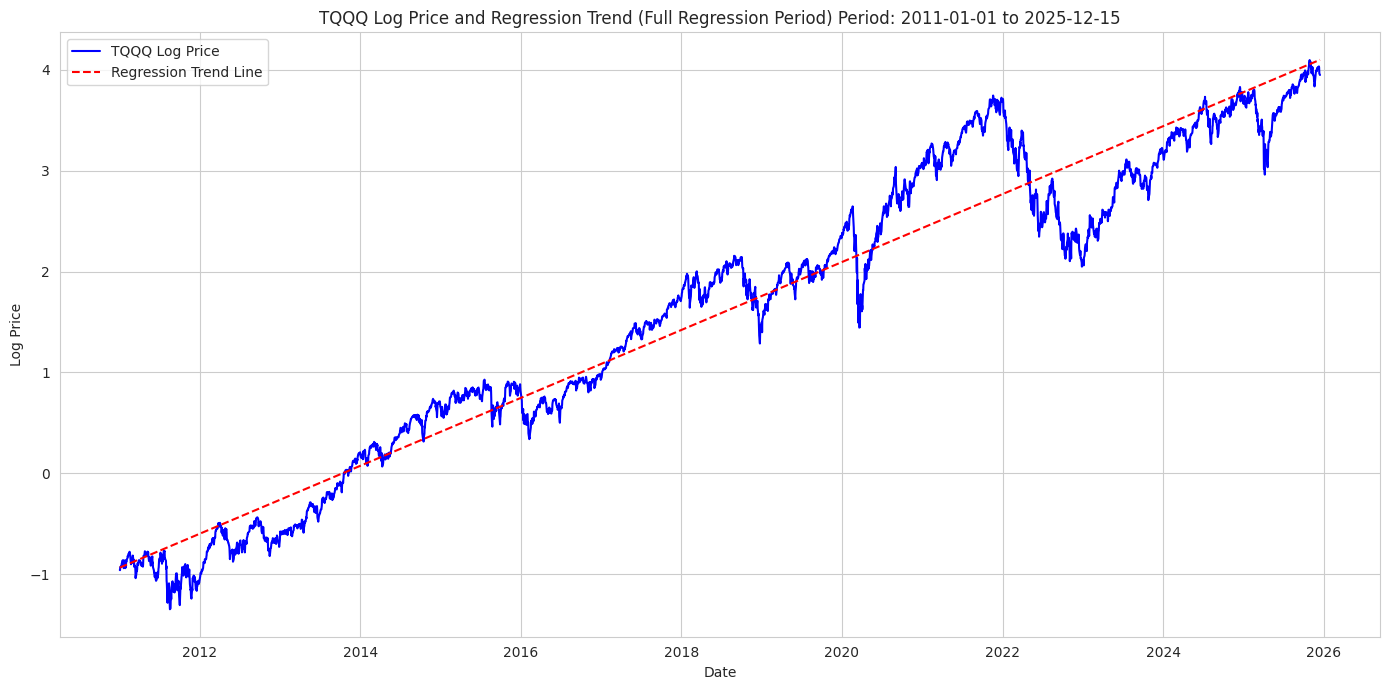

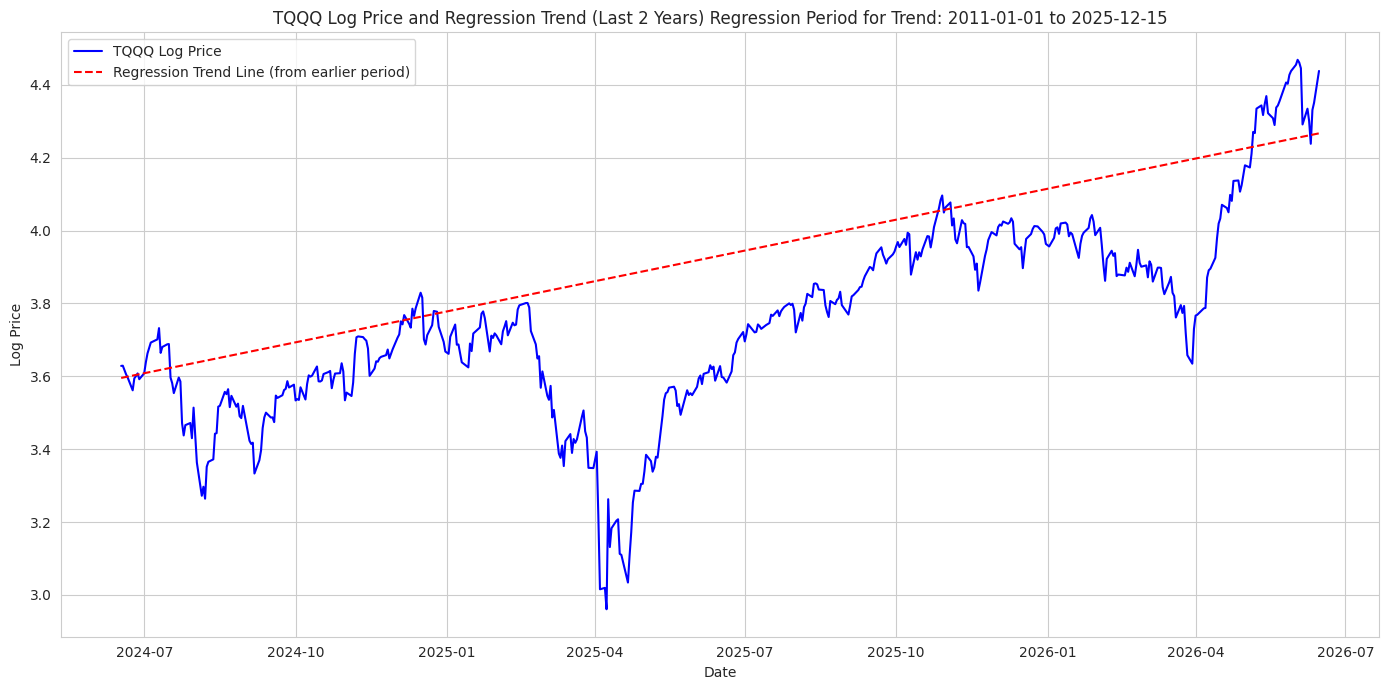


Final Recommended Allocation from Estimator: 23.18%


In [191]:
# Example usage with optimized parameters
recommended_allocation = get_tqqq_allocation_estimator(k_factor=7.0, min_allocation=0.00)
print(f"\nFinal Recommended Allocation from Estimator: {recommended_allocation:.2%}")